In [1]:
# Import Required Libraries
import pandas as pd
import zipfile
import os

In [2]:
# Unzip SSTI.zip
with zipfile.ZipFile("SSTI.zip", "r") as zip_ref:
    zip_ref.extractall("ssti__data")

In [5]:
# Check What Files Are Inside
os.listdir("ssti__data")

['Disease_symptom_and_patient_profile_dataset.csv', 'SSTI.csv']

In [6]:
data = pd.read_csv("ssti__data/SSTI.csv")

In [7]:
data.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Osteoarthritis,Yes,No,Yes,No,39,Male,Normal,Low,Negative
1,Psoriasis,No,No,Yes,No,41,Male,Low,Normal,Positive
2,Eczema,Yes,No,No,No,26,Female,Normal,Normal,Positive
3,Glaucoma,No,No,Yes,No,39,Male,High,Normal,Negative
4,Psoriasis,No,Yes,No,No,41,Female,Normal,High,Positive


In [8]:
data.shape

(1800, 10)

In [9]:
data.columns

Index(['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age',
       'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable'],
      dtype='object')

In [10]:
# NORMALIZE COLUMN NAMES
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [11]:
# REMOVE IRRELEVANT FEATURES
if "cough" in data.columns:
    data.drop("cough" , axis=1, inplace=True)


In [12]:
data = data.drop("disease", axis=1)

In [13]:
data.head()
data.shape

(1800, 8)

In [14]:
def safe_mode(series):
    mode_val = series.mode()
    if len(mode_val) > 0:
        return mode_val.iloc[0]
    else:
        return 0   # default for binary features

In [15]:
#NORMALIZE 
binary_cols = [
    "fever",
    "fatigue",
    "difficulty_breathing"
]

# Normalize text first 
for col in binary_cols:
    data[col] = data[col].astype(str).str.lower().str.strip()

# Map yes/no 
for col in binary_cols:
    data[col] = data[col].map({"yes": 1, "no": 0})

# Fill missing values 
for col in binary_cols:
    data[col] = data[col].fillna(safe_mode(data[col]))

In [16]:
#  NORMALIZE GENDER VALUES
data["gender"] = data["gender"].astype(str).str.lower().str.strip()

In [17]:
# MAP GENDER TO NUMERIC
data["gender"] = data["gender"].replace({
    "male": 1,
    "m": 1,
    "female": 0,
    "f": 0
})


C:\Users\furka\AppData\Local\Temp\ipykernel_10780\3893816348.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["gender"] = data["gender"].replace({


In [18]:
# Safe mode function
def safe_mode(series):
    mode_val = series.mode()
    return mode_val.iloc[0] if len(mode_val) > 0 else 0

# Fill missing gender
data["gender"] = data["gender"].fillna(safe_mode(data["gender"]))

In [19]:
data.columns

Index(['fever', 'fatigue', 'difficulty_breathing', 'age', 'gender',
       'blood_pressure', 'cholesterol_level', 'outcome_variable'],
      dtype='object')

In [20]:
print(data["blood_pressure" ].dtype)
print(data["cholesterol_level" ].dtype)
print(data["outcome_variable" ].dtype)

object
object
object


In [21]:
# Encode categorical text features
# Encode blood pressure
data["blood_pressure"] = data["blood_pressure"].map({
    "Low": 0,
    "Normal": 1,
    "High": 2
})

# Encode cholesterol
data["cholesterol_level"] = data["cholesterol_level"].map({
    "Low": 0,
    "Normal": 1,
    "High": 2
})

# Encode outcome variable
data["outcome_variable"] = data["outcome_variable"].map({
    "Negative": 0,
    "Positive": 1
})


In [23]:
# Check Missing Values
data.isnull().sum()

fever                   0
fatigue                 0
difficulty_breathing    0
age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
outcome_variable        0
dtype: int64


Categorical SSTI clinical features were encoded numerically, and missing values were handled using mode imputation to ensure robustness.”

In [25]:
# ADD SSTI-SPECIFIC FEATURES : Additional SSTI-specific clinical features were simulated to reflect real-world outpatient presentations
import numpy as np
np.random.seed(42)

skin_inflammation = []
local_pain = []
pus_or_abscess = []

heart_rates = []
resp_rates = []
bps = []
platelets = []

for _, row in data.iterrows():

    # SSTI severity indicators
    severe_case = (
        row["fever"] == 1 or
        row["outcome_variable"] == 1
    )

    # SSTI-specific features
    if severe_case:

        skin_inflammation.append(
            np.random.choice([1, 1, 1, 0])
        )

        local_pain.append(
            np.random.choice([1, 1, 0])
        )

        pus_or_abscess.append(
            np.random.choice([1, 1, 0])
        )

        # Severe sepsis vitals
        heart_rates.append(
            np.random.normal(110, 8)
        )

        resp_rates.append(
            np.random.normal(24, 3)
        )

        bps.append(
            np.random.normal(95, 10)
        )

        platelets.append(
            np.random.normal(140000, 25000)
        )

    else:

        skin_inflammation.append(
            np.random.choice([0, 0, 1])
        )

        local_pain.append(
            np.random.choice([0, 1])
        )

        pus_or_abscess.append(
            np.random.choice([0, 0, 1])
        )

        # Mild vitals
        heart_rates.append(
            np.random.normal(85, 6)
        )

        resp_rates.append(
            np.random.normal(18, 2)
        )

        bps.append(
            np.random.normal(118, 8)
        )

        platelets.append(
            np.random.normal(220000, 30000)
        )

# Add features
data["skin_inflammation"] = np.array(
    skin_inflammation
).astype(int)

data["local_pain"] = np.array(
    local_pain
).astype(int)

data["pus_or_abscess"] = np.array(
    pus_or_abscess
).astype(int)

data["heart_rate"] = np.array(
    heart_rates
).astype(int)

data["respiratory_rate"] = np.array(
    resp_rates
).astype(int)

data["systolic_bp"] = np.array(
    bps
).astype(int)

data["platelets"] = np.array(
    platelets
).astype(int)


In [26]:
#CCREATE SEPSIS RISK LABEL
def assign_sepsis_risk(row):

    score = 0

    if row["fever"] == 1:
        score += 1

    if row["heart_rate"] > 100:
        score += 1

    if row["respiratory_rate"] > 22:
        score += 1

    if row["systolic_bp"] < 100:
        score += 1

    if row["skin_inflammation"] == 1:
        score += 1

    if row["platelets"] < 150000:
        score += 1

    if row["pus_or_abscess"] == 1:
        score += 1

    if score >= 4:
        return "High"

    elif score >= 3:
        return "Medium"

    else:
        return "Low"


In [27]:
# Apply Sepsis Risk Label
data["sepsis_risk"] = data.apply(assign_sepsis_risk, axis=1)

In [28]:
# Check Risk Distribution
data["sepsis_risk"].value_counts()

sepsis_risk
High      1160
Low        530
Medium     110
Name: count, dtype: int64

In [29]:
# Final Sanity Check
data.head()
data.isnull().sum()

fever                   0
fatigue                 0
difficulty_breathing    0
age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
outcome_variable        0
skin_inflammation       0
local_pain              0
pus_or_abscess          0
heart_rate              0
respiratory_rate        0
systolic_bp             0
platelets               0
sepsis_risk             0
dtype: int64

In [32]:
# Save Final SSTI Dataset
data.to_csv("ssti2_sepsis_ready.csv", index=False)

In [33]:
# Load the Final SSTI Dataset
import pandas as pd

data = pd.read_csv("ssti2_sepsis_ready.csv")
data.head()

,fever,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,skin_inflammation,local_pain,pus_or_abscess,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,1,1,0,39,1,1,0,0,1,1,0,115,28,92,134146,High
1,0,1,0,41,1,0,1,1,1,0,1,122,26,90,153564,High
2,1,0,0,26,0,1,1,1,0,1,1,111,18,77,125942,High
3,0,1,0,39,1,2,1,0,1,0,0,83,17,106,264609,Low
4,0,0,0,41,0,1,2,1,0,1,0,113,26,92,139254,High


In [34]:
data.shape
data["sepsis_risk"].value_counts()

sepsis_risk
High      1160
Low        530
Medium     110
Name: count, dtype: int64

In [35]:
data.dtypes

fever                    int64
fatigue                  int64
difficulty_breathing     int64
age                      int64
gender                   int64
blood_pressure           int64
cholesterol_level        int64
outcome_variable         int64
skin_inflammation        int64
local_pain               int64
pus_or_abscess           int64
heart_rate               int64
respiratory_rate         int64
systolic_bp              int64
platelets                int64
sepsis_risk             object
dtype: object

In [36]:
# Separate Features (X) and Target (y)
X = data.drop("sepsis_risk", axis=1)
y = data["sepsis_risk"]

In [37]:
# Encode Target Labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(le.classes_)     # We used label encoding for the multi-class sepsis risk variable.

['High' 'Low' 'Medium']


In [38]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# SCALE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE ONLY ON TRAIN
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [39]:
#RANDOM FOREST + GRID SEARCH

# GRID SEARCH
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 12, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(
    X_train_resampled,
    y_train_resampled
)

rf_ssti = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [40]:
# Predictions
y_pred = rf_ssti.predict(X_test_scaled)
# Get full probability matrix
y_proba = rf_ssti.predict_proba(X_test_scaled)

In [41]:
# EXTRACT HIGH-RISK PROBABILITY
# Find index of "High"
high_risk_index = list(le.classes_).index("High")
# Extract High-risk probability
y_high_risk_prob = y_proba[:, high_risk_index]


In [42]:
# Sepsis Risk Level Classification
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"



In [44]:
# Apply risk level classification
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]

In [45]:
# CREATE SSTI RESULTS DATAFRAME
results_ssti = pd.DataFrame({

    "Disease": "SSTI",

    "Actual_Sepsis":
        le.inverse_transform(y_test),

    "Predicted_Sepsis":
        le.inverse_transform(y_pred),

    "Sepsis_Probability":
        y_high_risk_prob,

    "Sepsis_Risk_Level":
        risk_levels
})

print(results_ssti.head())

  Disease Actual_Sepsis Predicted_Sepsis  Sepsis_Probability Sepsis_Risk_Level
0    SSTI          High             High            0.585017     Moderate Risk
1    SSTI          High             High            0.926053         High Risk
2    SSTI           Low              Low            0.000000          Low Risk
3    SSTI           Low              Low            0.045236          Low Risk
4    SSTI          High             High            0.921527         High Risk


In [46]:
# CHECK SEPSIS RISK DISTRIBUTION
print(
    results_ssti[
        "Sepsis_Risk_Level"
    ].value_counts()
)


Sepsis_Risk_Level
High Risk        217
Low Risk         114
Moderate Risk     29
Name: count, dtype: int64


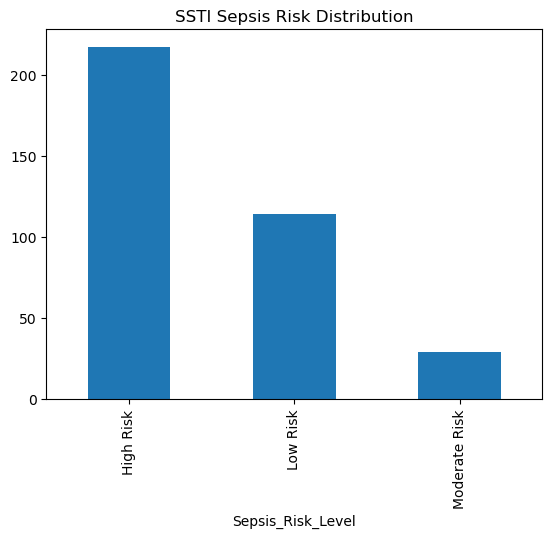

In [47]:
import matplotlib.pyplot as plt

results_ssti[
    "Sepsis_Risk_Level"
].value_counts().plot(
    kind="bar",
    title="SSTI Sepsis Risk Distribution"
)

plt.show()


In [48]:
# Evaluate Model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("SSTI Random Forest Accuracy:", accuracy)

SSTI Random Forest Accuracy: 0.9388888888888889


In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))


Precision: 0.9446581196581197
Recall: 0.9388888888888889
F1-score: 0.9412878410828847


In [57]:
#  ROC AUC SCORE
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

auc = roc_auc_score(
    y_test_bin,
    y_proba,
    multi_class="ovr"
)

print("ROC-AUC Score:", auc)


ROC-AUC Score: 0.9802786329313978


In [58]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


              precision    recall  f1-score   support

        High       0.96      0.97      0.97       232
         Low       1.00      0.94      0.97       106
      Medium       0.50      0.59      0.54        22

    accuracy                           0.94       360
   macro avg       0.82      0.83      0.83       360
weighted avg       0.94      0.94      0.94       360



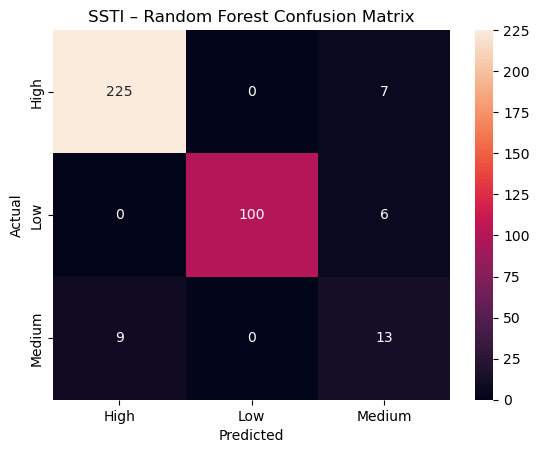

In [59]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SSTI – Random Forest Confusion Matrix")
plt.show()


                 Feature  Importance
11            heart_rate    0.177648
14             platelets    0.164985
12      respiratory_rate    0.155541
13           systolic_bp    0.106461
0                  fever    0.096654
10        pus_or_abscess    0.070780
7       outcome_variable    0.063302
8      skin_inflammation    0.050019
3                    age    0.024799
6      cholesterol_level    0.022177
5         blood_pressure    0.017708
1                fatigue    0.015837
9             local_pain    0.015082
4                 gender    0.010654
2   difficulty_breathing    0.008354


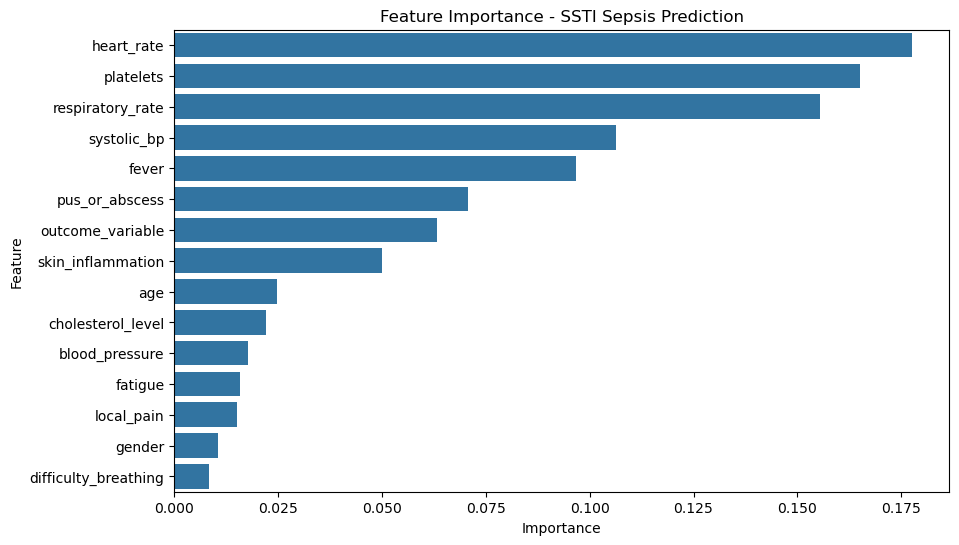

In [60]:
# Feature Importance
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf_ssti.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title(
    "Feature Importance - SSTI Sepsis Prediction"
)

plt.show()


In [61]:
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_ssti,
    X_train_resampled,
    y_train_resampled,
    cv=10
)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.9863528532013099


In [62]:
# Save Model & Scaler
import joblib
joblib.dump(rf_ssti, "ssti_random_forest_model.pkl")
joblib.dump(scaler, "ssti_scaler.pkl")
joblib.dump(le, "ssti_label_encoder.pkl")
joblib.dump(list(X.columns), "models/ssti_features.pkl")

['models/ssti_features.pkl']

In [63]:
results_ssti.to_csv("results_ssti.csv", index=False)